# Lab: K-Nearest Neighbors Classifier

*This notebook demonstrates a complete data science workflow for building a KNN classifier, including the critical steps of feature scaling and hyperparameter tuning.*

---

## Stage 1: Business Understanding

Let's start by understanding the problem from a business perspective.

*   **Scenario:** We are data scientists for a telecommunications provider. The company has already segmented its customer base into four groups based on service usage patterns.
*   **Business Objective:** To build a model that can predict which of the four customer groups a new customer will belong to based on their demographic data (e.g., region, age, marital status). This will allow the company to customize marketing offers for prospective customers.

---

## Stage 2: Analytic Approach

With the business problem defined, we select an analytic approach.

*   **Problem Framing:** The goal is to assign a new customer to one of four predefined categories. This is a **multi-class classification** problem.
*   **Candidate Model:** We will use the **K-Nearest Neighbors (KNN)** algorithm. It's a great choice for a first attempt because it's easy to understand and implement.
*   **Evaluation Metric:** We will first check the class distribution. If the classes are relatively balanced, we can use **accuracy** as our primary evaluation metric. Accuracy measures the proportion of total predictions that were correct.

---

## Stage 3: Data Requirements

To build our model, we need a dataset containing customer demographic data and their corresponding service usage category. The provided dataset, `teleCust1000t.csv`, contains features like `region`, `tenure`, `age`, `marital`, `income`, and the target variable `custcat`.

---

## Stage 4: Data Collection

The data is available from a public URL. To ensure our project is robust and reproducible, we will first download the data to a local `./data` directory and then load it from there using `pathlib`.

In [12]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Configurations
plt.style.use('fivethirtyeight')
pd.set_option('display.max_columns', None)

In [5]:
# --- Data Download and Loading ---

# Define the local data directory and file path using pathlib
data_dir = Path("./data")
file_path = data_dir / "teleCust1000t.csv"
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/teleCust1000t.csv"

# Create the data directory if it doesn't exist
if not data_dir.exists():
    data_dir.mkdir(parents=True)
    print(f"Directory '{data_dir}' created.")

# Download the file if it doesn't already exist
if not file_path.exists():
    print(f"Downloading data from {url}...")
    try:
        response = requests.get(url, stream=True)
        response.raise_for_status()
        with open(file_path, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        print(f"Data successfully downloaded and saved to '{file_path}'.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading data: {e}")
else:
    print(f"Data file already exists at '{file_path}'.")

# Load the data from the local file
try:
    df = pd.read_csv(file_path)
    print("DataFrame loaded successfully from local file.")
except Exception as e:
    print(f"Error loading data into DataFrame: {e}")

df.head()

Data file already exists at 'data/teleCust1000t.csv'.
DataFrame loaded successfully from local file.


,region,tenure,age,marital,address,income,ed,employ,retire,gender,reside,custcat
0,2,13,44,1,9,64.0,4,5,0.0,0,2,1
1,3,11,33,1,7,136.0,5,5,0.0,0,6,4
2,3,68,52,1,24,116.0,1,29,0.0,1,2,3
3,2,33,33,0,12,33.0,2,0,0.0,1,1,1
4,2,23,30,1,9,30.0,1,2,0.0,0,4,3


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   region   1000 non-null   int64  
 1   tenure   1000 non-null   int64  
 2   age      1000 non-null   int64  
 3   marital  1000 non-null   int64  
 4   address  1000 non-null   int64  
 5   income   1000 non-null   float64
 6   ed       1000 non-null   int64  
 7   employ   1000 non-null   int64  
 8   retire   1000 non-null   float64
 9   gender   1000 non-null   int64  
 10  reside   1000 non-null   int64  
 11  custcat  1000 non-null   int64  
dtypes: float64(2), int64(10)
memory usage: 93.9 KB



---

## Stage 5: Data Understanding

Let's perform Exploratory Data Analysis to understand the data's characteristics, starting with the class distribution.

In [6]:
# Check the distribution of the target variable 'custcat'
class_counts = df['custcat'].value_counts().sort_index()
print(class_counts)

custcat
1    266
2    217
3    281
4    236
Name: count, dtype: int64



> 📊 **Data Understanding Report:**
>
> *   The four customer categories are: 1-Basic, 2-E-Service, 3-Plus, 4-Total.
> *   The classes are relatively balanced (266, 217, 281, 236 customers in each). This confirms that **accuracy** is a suitable evaluation metric for this problem.
> *   The dataset contains 1000 records and 12 columns. All features are numerical, which simplifies preprocessing.

---

## Stage 6: Data Preparation

This stage involves preparing the final dataset for modeling. For KNN, this stage is critical.

#### 6.1 Final Dataset Split

First, we separate the data into the feature matrix (`X`) and the target vector (`y`). Then, we perform the train-test split *before* any scaling to prevent data leakage.

In [17]:
# X contains our independent variables. We drop the target 'custcat'.
X = df.drop('custcat', axis=1)

# y contains our dependent variable (the target)
y = df['custcat']

# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### 6.2 Feature Scaling

**This is the most important step for KNN.** The algorithm relies on calculating distances between data points. If features have different scales (e.g., `income` vs. `age`), the features with larger scales will unfairly dominate the distance calculation. `StandardScaler` standardizes features by removing the mean and scaling to unit variance.

In [18]:
# Create a StandardScaler object
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Use the same fitted scaler to transform the test data
X_test_scaled = scaler.transform(X_test)


---

## Stage 7 & 8: Modeling and Evaluation

Now we will build and evaluate our KNN model. The most important hyperparameter for KNN is `k`, the number of neighbors to consider. Finding the optimal `k` is key to building a good model.

### Finding the Optimal `k`

We will train and evaluate the KNN model for a range of `k` values and plot the accuracy for each. This will help us find the "sweet spot" that balances bias and variance.

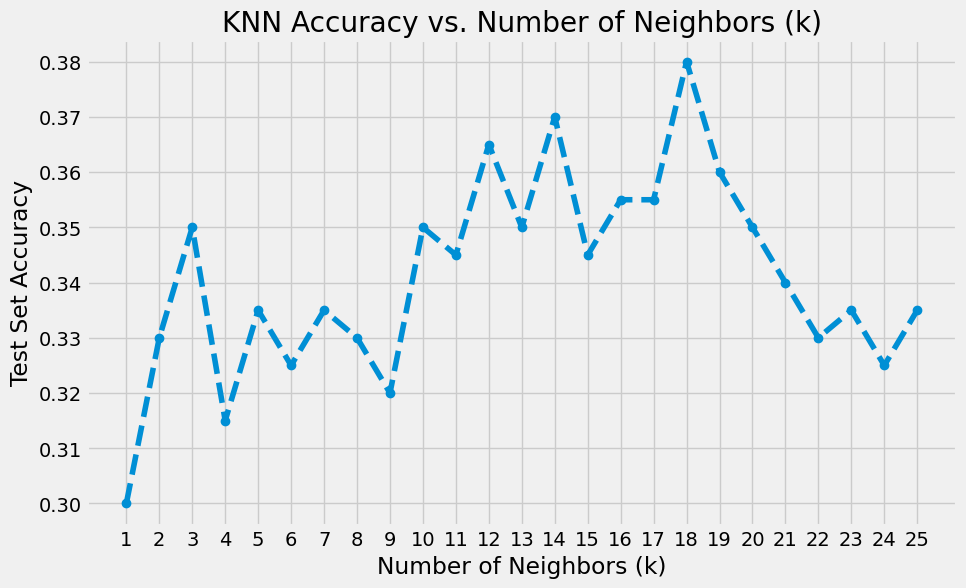

The best accuracy was 0.380 with k = 18


In [21]:
# Find the optimal k value
k_range = range(1, 26)  # Test k from 1 to 25
accuracies = []

for k in k_range:
    # Create and train the KNN model
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    # Make predictions on the test set
    y_pred = knn.predict(X_test_scaled)
    
    # Calculate and store the accuracy
    accuracies.append(accuracy_score(y_test, y_pred))

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(k_range, accuracies, marker='o', linestyle='dashed')
plt.title('KNN Accuracy vs. Number of Neighbors (k)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Test Set Accuracy')
plt.xticks(k_range)
plt.grid(True)
plt.show()

# Find the best k and its corresponding accuracy
best_k = k_range[np.argmax(accuracies)]
best_accuracy = max(accuracies)

print(f"The best accuracy was {best_accuracy:.3f} with k = {best_k}")


---

## Stage 9: Deployment (Conceptual)

The model is now trained and evaluated. If deployed, it would operate as follows:
1.  A new customer's demographic data is collected.
2.  The data is passed through the same `StandardScaler` that was fitted on the training data.
3.  The scaled data is fed into the trained KNN model (using the optimal `k` value we found).
4.  The model predicts the customer's service category, allowing for a customized marketing offer to be presented.

---

## Stage 10: Conclusion

In this lab, we successfully built a K-Nearest Neighbors classifier to predict customer service usage patterns.

*   We performed essential preprocessing, emphasizing the critical importance of **feature scaling** for a distance-based algorithm like KNN.
*   Through systematic hyperparameter tuning, we identified that the optimal `k` for this dataset is **18**, yielding a test accuracy of **38%**.
*   **Analysis of Results:** While an absolute accuracy of 38% is low for a production system, it must be compared to a baseline. For this 4-class problem, a random-guess model would have an accuracy of 25%. Our model's performance represents a **significant improvement over random chance**, proving that it successfully learned predictive patterns from the data.
*   The relatively low final accuracy is a valuable finding in itself: it suggests that the demographic features in this dataset have **limited predictive power**. To improve performance, a next step would be to engineer new features or collect different types of data (e.g., web usage, call records).

This exercise successfully demonstrates the complete machine learning workflow, from understanding the business problem to drawing actionable conclusions from a model's performance.

---

**Next:** [Bias, Variance, and Ensemble Models](./11_bias_variance_and_ensemble_models.md)